In [1]:
# ============================================================
# PHASE E — CELL 1
# ROBUSTNESS EVALUATION ENVIRONMENT
# ============================================================

import os
import io
import json
import time
import random
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from torchvision.models import resnet50, efficientnet_b0

from PIL import (
    Image,
    ImageFilter,
    ImageEnhance,
    ImageDraw
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

warnings.filterwarnings("ignore")


# ============================================================
# REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ============================================================
# CONFIGURATION
# ============================================================

IMG_SIZE = 224

BATCH_SIZE = 32

NUM_WORKERS = 2

NUM_CLASSES = 14


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

PIN_MEMORY = torch.cuda.is_available()


# ============================================================
# IMAGENET NORMALIZATION
# ============================================================

IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]


# ============================================================
# DISPLAY ENVIRONMENT
# ============================================================

print("=" * 72)

print(
    "PHASE E — CORRUPTION ROBUSTNESS EVALUATION"
)

print("=" * 72)

print(
    "PyTorch :",
    torch.__version__
)

print(
    "CUDA    :",
    torch.cuda.is_available()
)

print(
    "Device  :",
    DEVICE
)

if torch.cuda.is_available():

    print(
        "GPU     :",
        torch.cuda.get_device_name(0)
    )


print(
    "\nKaggle inputs:"
)

for item in os.listdir(
    "/kaggle/input"
):

    print(
        " -",
        item
    )


print(
    "\n✅ PHASE E ENVIRONMENT READY"
)

print(
    "🔒 No model training or tuning will be performed."
)

PHASE E — CORRUPTION ROBUSTNESS EVALUATION
PyTorch : 2.10.0+cu128
CUDA    : True
Device  : cuda
GPU     : Tesla T4

Kaggle inputs:
 - datasets

✅ PHASE E ENVIRONMENT READY
🔒 No model training or tuning will be performed.


In [2]:
# ============================================================
# PHASE E — CELL 2
# FIND LOCKED TEST SET + FINAL MODEL CHECKPOINTS
# ============================================================

from pathlib import Path


IMAGE_EXTENSIONS = (
    ".jpg", ".jpeg", ".png",
    ".bmp", ".tif", ".tiff", ".webp"
)


# ============================================================
# COUNT IMAGES
# ============================================================

def count_images_recursive(folder):

    total = 0

    for root, dirs, files in os.walk(folder):

        total += sum(

            1 for file in files

            if file.lower().endswith(
                IMAGE_EXTENSIONS
            )
        )

    return total


def count_direct_folders(folder):

    try:

        return len([
            d for d in os.listdir(folder)
            if os.path.isdir(
                os.path.join(folder, d)
            )
        ])

    except:

        return 0


# ============================================================
# FIND LOCKED TEST SET
# ============================================================

TEST_DIR = None


for root, dirs, files in os.walk(
    "/kaggle/input"
):

    if count_direct_folders(root) == 14:

        n_images = count_images_recursive(
            root
        )

        if n_images == 157:

            TEST_DIR = root

            break


# ============================================================
# COLLECT ALL INPUT FILES
# ============================================================

ALL_FILES = []


for root, dirs, files in os.walk(
    "/kaggle/input"
):

    for file in files:

        ALL_FILES.append(
            os.path.join(root, file)
        )


# ============================================================
# SEARCH DIRECT .PTH FILES
# ============================================================

def find_checkpoint(
    model_word,
    stage_word
):

    matches = []

    for path in ALL_FILES:

        name = os.path.basename(
            path
        ).lower()

        if not name.endswith(".pth"):
            continue

        if (
            model_word.lower() in name
            and stage_word.lower() in name
            and "best" in name
        ):

            matches.append(path)


    if len(matches) > 0:

        return matches[0]

    return None


RESNET_FINETUNED_PTH = find_checkpoint(
    "resnet50",
    "finetuned"
)


EFFNET_FINETUNED_PTH = find_checkpoint(
    "efficientnet",
    "finetuned"
)


# ============================================================
# ZIP FALLBACK
# ============================================================

if (
    RESNET_FINETUNED_PTH is None
    or EFFNET_FINETUNED_PTH is None
):

    EXTRACT_ROOT = (
        "/kaggle/working/"
        "phaseE_extracted"
    )

    os.makedirs(
        EXTRACT_ROOT,
        exist_ok=True
    )


    zip_files = [

        path

        for path in ALL_FILES

        if path.lower().endswith(".zip")

    ]


    for zip_path in zip_files:

        filename = os.path.basename(
            zip_path
        ).lower()


        if (
            "resnet" in filename
            or "efficientnet" in filename
        ):

            target = os.path.join(

                EXTRACT_ROOT,

                Path(
                    zip_path
                ).stem
            )

            os.makedirs(
                target,
                exist_ok=True
            )


            try:

                with zipfile.ZipFile(
                    zip_path,
                    "r"
                ) as z:

                    z.extractall(
                        target
                    )

            except:

                pass


    # Add extracted files
    for root, dirs, files in os.walk(
        EXTRACT_ROOT
    ):

        for file in files:

            ALL_FILES.append(
                os.path.join(
                    root,
                    file
                )
            )


    # Search again
    RESNET_FINETUNED_PTH = find_checkpoint(
        "resnet50",
        "finetuned"
    )

    EFFNET_FINETUNED_PTH = find_checkpoint(
        "efficientnet",
        "finetuned"
    )


# ============================================================
# DISPLAY RESULTS
# ============================================================

print("=" * 72)

print(
    "PHASE E RESOURCE DETECTION"
)

print("=" * 72)


print(
    "\nLocked Test:"
)

print(
    TEST_DIR
)


print(
    "\nResNet50 Fine-tuned:"
)

print(
    RESNET_FINETUNED_PTH
)


print(
    "\nEfficientNet-B0 Fine-tuned:"
)

print(
    EFFNET_FINETUNED_PTH
)


# ============================================================
# FINAL VALIDATION
# ============================================================

assert TEST_DIR is not None, \
    "❌ Locked Test set was not found."


assert count_images_recursive(
    TEST_DIR
) == 157, \
    "❌ Test set does not contain exactly 157 images."


assert RESNET_FINETUNED_PTH is not None, \
    "❌ ResNet50 fine-tuned checkpoint was not found."


assert EFFNET_FINETUNED_PTH is not None, \
    "❌ EfficientNet-B0 fine-tuned checkpoint was not found."


print(
    "\n" + "=" * 72
)

print(
    "✅ ALL PHASE E RESOURCES FOUND"
)

print(
    "=" * 72
)

print(
    "✅ Locked Test = 157 images"
)

print(
    "✅ ResNet50 Fine-tuned checkpoint"
)

print(
    "✅ EfficientNet-B0 Fine-tuned checkpoint"
)

PHASE E RESOURCE DETECTION

Locked Test:
/kaggle/input/datasets/srabondcosta/aqua-plant-final-dataset/AquPlantDS_FINAL/Test

ResNet50 Fine-tuned:
/kaggle/input/datasets/srabondcosta/resnet50/resnet50_finetuned_best.pth

EfficientNet-B0 Fine-tuned:
/kaggle/input/datasets/srabondcosta/efficientnetb0/efficientnet_b0_finetuned_best.pth

✅ ALL PHASE E RESOURCES FOUND
✅ Locked Test = 157 images
✅ ResNet50 Fine-tuned checkpoint
✅ EfficientNet-B0 Fine-tuned checkpoint


In [3]:
# ============================================================
# PHASE E — CELL 3
# LOAD CLEAN TEST SET + LOAD FINAL MODELS
# ============================================================

# ------------------------------------------------------------
# CLEAN TEST TRANSFORM
# ------------------------------------------------------------

clean_test_transform = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


# ------------------------------------------------------------
# TEST DATASET
# ------------------------------------------------------------

clean_test_dataset = datasets.ImageFolder(

    TEST_DIR,

    transform=clean_test_transform
)


clean_test_loader = DataLoader(

    clean_test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=PIN_MEMORY
)


CLASS_NAMES = clean_test_dataset.classes


print("=" * 72)
print("CLEAN LOCKED TEST SET")
print("=" * 72)

print(
    "Images  :",
    len(clean_test_dataset)
)

print(
    "Classes :",
    len(CLASS_NAMES)
)


print("\nClass mapping:")

for cls, idx in clean_test_dataset.class_to_idx.items():

    print(
        idx,
        "->",
        cls
    )


assert len(clean_test_dataset) == 157
assert len(CLASS_NAMES) == 14


# ============================================================
# CHECKPOINT LOADING UTILITIES
# ============================================================

def safe_torch_load(
    path,
    map_location="cpu"
):

    try:

        return torch.load(
            path,
            map_location=map_location,
            weights_only=False
        )

    except TypeError:

        return torch.load(
            path,
            map_location=map_location
        )


def extract_state_dict(
    checkpoint
):

    if not isinstance(
        checkpoint,
        dict
    ):

        return checkpoint


    possible_keys = [

        "model_state_dict",

        "state_dict",

        "model",

        "weights"
    ]


    for key in possible_keys:

        if (
            key in checkpoint
            and isinstance(
                checkpoint[key],
                dict
            )
        ):

            return checkpoint[key]


    if all(

        isinstance(k, str)

        for k in checkpoint.keys()

    ):

        if any(

            k.endswith(".weight")
            or k.endswith(".bias")

            for k in checkpoint.keys()

        ):

            return checkpoint


    raise RuntimeError(

        "Could not identify state_dict."
    )


def remove_module_prefix(
    state_dict
):

    clean_dict = {}


    for key, value in state_dict.items():

        if key.startswith(
            "module."
        ):

            key = key[
                len("module.") :
            ]


        clean_dict[key] = value


    return clean_dict


# ============================================================
# EXACT RESNET50 ARCHITECTURE
# ============================================================

def build_resnet50():

    model = resnet50(
        weights=None
    )


    num_features = (
        model.fc.in_features
    )


    model.fc = nn.Sequential(

        nn.Dropout(
            p=0.3
        ),

        nn.Linear(

            num_features,

            NUM_CLASSES
        )
    )


    return model


# ============================================================
# EXACT EFFICIENTNET-B0 ARCHITECTURE
# ============================================================

def build_efficientnet_b0():

    model = efficientnet_b0(
        weights=None
    )


    num_features = (
        model.classifier[1].in_features
    )


    model.classifier = nn.Sequential(

        nn.Dropout(

            p=0.3,

            inplace=True
        ),

        nn.Linear(

            num_features,

            NUM_CLASSES
        )
    )


    return model


# ============================================================
# LOAD MODEL CHECKPOINT
# ============================================================

def load_model(
    model,
    checkpoint_path
):

    checkpoint = safe_torch_load(

        checkpoint_path,

        map_location=DEVICE
    )


    state_dict = extract_state_dict(
        checkpoint
    )


    state_dict = remove_module_prefix(
        state_dict
    )


    model.load_state_dict(

        state_dict,

        strict=True
    )


    model = model.to(
        DEVICE
    )


    model.eval()


    return model


# ============================================================
# LOAD FINAL MODELS
# ============================================================

resnet_model = load_model(

    build_resnet50(),

    RESNET_FINETUNED_PTH
)


effnet_model = load_model(

    build_efficientnet_b0(),

    EFFNET_FINETUNED_PTH
)


print("\n" + "=" * 72)

print(
    "FINAL MODELS"
)

print("=" * 72)


print(
    "✅ ResNet50 Fine-tuned loaded"
)

print(
    "✅ EfficientNet-B0 Fine-tuned loaded"
)

print(
    "✅ Both models set to evaluation mode"
)

print(
    "🔒 No training parameters will be updated"
)

CLEAN LOCKED TEST SET
Images  : 157
Classes : 14

Class mapping:
0 -> Class_10_lippia_alba
1 -> Class_11_marsilea_minuta
2 -> Class_12_duck_weeds
3 -> Class_13_topapana
4 -> Class_14_kachuripana
5 -> Class_1_water_iris
6 -> Class_2_pistia_stratiotes
7 -> Class_3_lily_leaf
8 -> Class_4_lotus-leaf
9 -> Class_5_water_popy
10 -> Class_6_salvania
11 -> Class_7_chinese_water_spinach
12 -> Class_8_water_plantain
13 -> Class_9_mexican_sword_lily

FINAL MODELS
✅ ResNet50 Fine-tuned loaded
✅ EfficientNet-B0 Fine-tuned loaded
✅ Both models set to evaluation mode
🔒 No training parameters will be updated


In [4]:
# ============================================================
# PHASE E — CELL 4
# CORRUPTION ENGINE
# 6 CORRUPTIONS × 3 SEVERITY LEVELS
# ============================================================

import io
import numpy as np

from PIL import (
    Image,
    ImageFilter,
    ImageEnhance,
    ImageDraw
)


# ============================================================
# CORRUPTION CONFIGURATION
# ============================================================

CORRUPTIONS = [

    "gaussian_blur",

    "gaussian_noise",

    "brightness",

    "contrast",

    "jpeg_compression",

    "occlusion"
]


SEVERITIES = [
    1,
    2,
    3
]


SEVERITY_NAMES = {

    1: "Mild",

    2: "Moderate",

    3: "Strong"
}


# ============================================================
# CORRUPTION PARAMETERS
# ============================================================

CORRUPTION_PARAMS = {

    # Gaussian blur radius
    "gaussian_blur": {
        1: 1.0,
        2: 2.0,
        3: 3.0
    },

    # Gaussian noise standard deviation
    # Pixel values are scaled to [0,1]
    "gaussian_noise": {
        1: 0.03,
        2: 0.06,
        3: 0.10
    },

    # Brightness reduction factor
    "brightness": {
        1: 0.80,
        2: 0.60,
        3: 0.40
    },

    # Contrast reduction factor
    "contrast": {
        1: 0.80,
        2: 0.60,
        3: 0.40
    },

    # JPEG quality
    "jpeg_compression": {
        1: 70,
        2: 40,
        3: 20
    },

    # Approximate occluded area
    "occlusion": {
        1: 0.10,
        2: 0.20,
        3: 0.30
    }
}


# ============================================================
# 1. GAUSSIAN BLUR
# ============================================================

def apply_gaussian_blur(
    image,
    severity
):

    radius = CORRUPTION_PARAMS[
        "gaussian_blur"
    ][severity]

    return image.filter(

        ImageFilter.GaussianBlur(
            radius=radius
        )
    )


# ============================================================
# 2. GAUSSIAN NOISE
# ============================================================

def apply_gaussian_noise(
    image,
    severity,
    rng
):

    std = CORRUPTION_PARAMS[
        "gaussian_noise"
    ][severity]


    image_array = np.asarray(
        image
    ).astype(
        np.float32
    ) / 255.0


    noise = rng.normal(

        loc=0.0,

        scale=std,

        size=image_array.shape

    ).astype(
        np.float32
    )


    noisy_image = (

        image_array
        + noise
    )


    noisy_image = np.clip(

        noisy_image,

        0.0,

        1.0
    )


    noisy_image = (

        noisy_image
        * 255.0

    ).astype(
        np.uint8
    )


    return Image.fromarray(
        noisy_image
    )


# ============================================================
# 3. BRIGHTNESS SHIFT
# ============================================================

def apply_brightness(
    image,
    severity
):

    factor = CORRUPTION_PARAMS[
        "brightness"
    ][severity]


    enhancer = ImageEnhance.Brightness(
        image
    )


    return enhancer.enhance(
        factor
    )


# ============================================================
# 4. CONTRAST REDUCTION
# ============================================================

def apply_contrast(
    image,
    severity
):

    factor = CORRUPTION_PARAMS[
        "contrast"
    ][severity]


    enhancer = ImageEnhance.Contrast(
        image
    )


    return enhancer.enhance(
        factor
    )


# ============================================================
# 5. JPEG COMPRESSION
# ============================================================

def apply_jpeg_compression(
    image,
    severity
):

    quality = CORRUPTION_PARAMS[
        "jpeg_compression"
    ][severity]


    buffer = io.BytesIO()


    image.save(

        buffer,

        format="JPEG",

        quality=quality
    )


    buffer.seek(0)


    compressed = Image.open(
        buffer
    ).convert(
        "RGB"
    )


    compressed.load()


    return compressed


# ============================================================
# 6. PARTIAL OCCLUSION
# ============================================================

def apply_occlusion(
    image,
    severity,
    rng
):

    image = image.copy()


    width, height = image.size


    area_fraction = CORRUPTION_PARAMS[
        "occlusion"
    ][severity]


    # Square whose area is approximately the requested
    # fraction of the total image area.

    side_fraction = np.sqrt(
        area_fraction
    )


    box_width = max(

        1,

        int(
            width
            * side_fraction
        )
    )


    box_height = max(

        1,

        int(
            height
            * side_fraction
        )
    )


    max_x = max(
        0,
        width - box_width
    )

    max_y = max(
        0,
        height - box_height
    )


    x1 = int(
        rng.integers(
            0,
            max_x + 1
        )
    )


    y1 = int(
        rng.integers(
            0,
            max_y + 1
        )
    )


    x2 = x1 + box_width

    y2 = y1 + box_height


    # Neutral gray occlusion
    fill_value = (
        127,
        127,
        127
    )


    draw = ImageDraw.Draw(
        image
    )


    draw.rectangle(

        [
            x1,
            y1,
            x2,
            y2
        ],

        fill=fill_value
    )


    return image


# ============================================================
# MASTER CORRUPTION FUNCTION
# ============================================================

def apply_corruption(
    image,
    corruption,
    severity,
    rng
):

    image = image.convert(
        "RGB"
    )


    if corruption == "gaussian_blur":

        return apply_gaussian_blur(
            image,
            severity
        )


    elif corruption == "gaussian_noise":

        return apply_gaussian_noise(
            image,
            severity,
            rng
        )


    elif corruption == "brightness":

        return apply_brightness(
            image,
            severity
        )


    elif corruption == "contrast":

        return apply_contrast(
            image,
            severity
        )


    elif corruption == "jpeg_compression":

        return apply_jpeg_compression(
            image,
            severity
        )


    elif corruption == "occlusion":

        return apply_occlusion(
            image,
            severity,
            rng
        )


    else:

        raise ValueError(

            f"Unknown corruption: {corruption}"
        )


# ============================================================
# VALIDATE CONFIGURATION
# ============================================================

TOTAL_CORRUPTED_CONDITIONS = (

    len(CORRUPTIONS)
    * len(SEVERITIES)

)


print("=" * 72)

print(
    "PHASE E CORRUPTION ENGINE"
)

print("=" * 72)


print(
    "\nCorruptions:"
)

for i, corruption in enumerate(
    CORRUPTIONS,
    start=1
):

    print(
        f"{i}. {corruption}"
    )


print(
    "\nSeverity levels:"
)

for severity in SEVERITIES:

    print(

        severity,

        "->",

        SEVERITY_NAMES[
            severity
        ]
    )


print(
    "\nTotal corruption conditions:",
    TOTAL_CORRUPTED_CONDITIONS
)


assert TOTAL_CORRUPTED_CONDITIONS == 18


print(
    "\n✅ 6 corruption types ready"
)

print(
    "✅ 3 severity levels ready"
)

print(
    "✅ Total = 18 corrupted Test conditions"
)

print(
    "✅ Noise and occlusion support deterministic random generation"
)

PHASE E CORRUPTION ENGINE

Corruptions:
1. gaussian_blur
2. gaussian_noise
3. brightness
4. contrast
5. jpeg_compression
6. occlusion

Severity levels:
1 -> Mild
2 -> Moderate
3 -> Strong

Total corruption conditions: 18

✅ 6 corruption types ready
✅ 3 severity levels ready
✅ Total = 18 corrupted Test conditions
✅ Noise and occlusion support deterministic random generation


CORRUPTED DATASET VERIFICATION
Images       : 157
Tensor shape : torch.Size([3, 224, 224])
Example label: 0


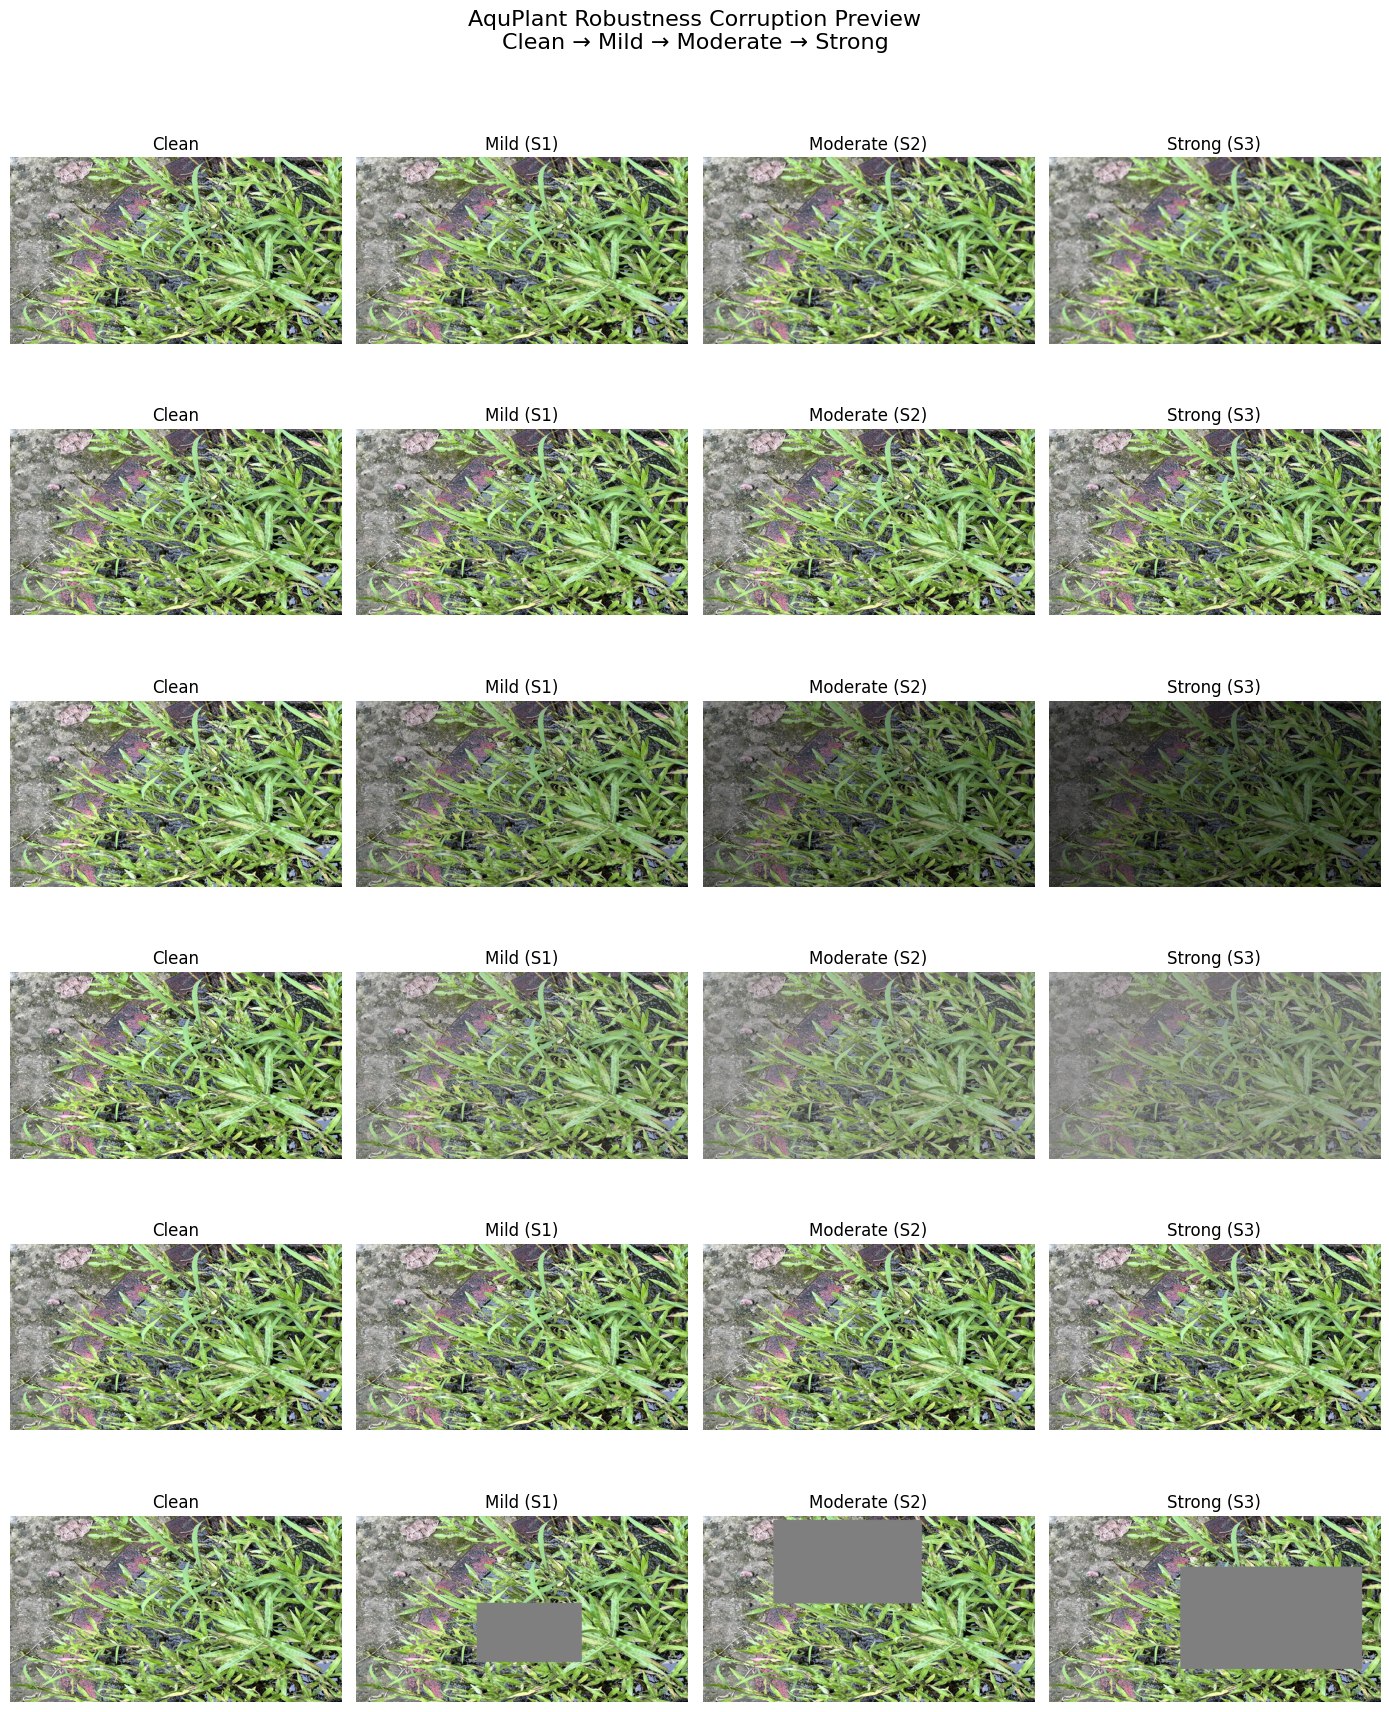


✅ Corrupted dataset works correctly
✅ All corrupted conditions remain 157 images
✅ Same deterministic corruption will be used for both models
✅ Preview saved:
/kaggle/working/phaseE_corruption_preview.png


In [5]:
# ============================================================
# PHASE E — CELL 5
# CORRUPTED TEST DATASET + VISUAL VERIFICATION
# ============================================================

from torch.utils.data import Dataset


# ============================================================
# FINAL TENSOR TRANSFORM
# Applied AFTER corruption
# ============================================================

evaluation_transform = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


# ============================================================
# DETERMINISTIC RANDOM SEED
# Same image + same corruption + same severity
# always gets exactly the same corrupted version
# ============================================================

def make_corruption_seed(
    image_index,
    corruption,
    severity
):

    corruption_id = (
        CORRUPTIONS.index(corruption)
        + 1
    )

    seed = (
        SEED
        + image_index * 1000
        + corruption_id * 100
        + severity * 10
    )

    return seed


# ============================================================
# CORRUPTED DATASET
# ============================================================

class CorruptedAquPlantDataset(Dataset):

    def __init__(
        self,
        samples,
        corruption,
        severity,
        transform=None
    ):

        self.samples = samples

        self.corruption = corruption

        self.severity = severity

        self.transform = transform


    def __len__(self):

        return len(
            self.samples
        )


    def __getitem__(
        self,
        index
    ):

        image_path, label = (
            self.samples[index]
        )


        image = Image.open(
            image_path
        ).convert(
            "RGB"
        )


        seed = make_corruption_seed(

            index,

            self.corruption,

            self.severity
        )


        rng = np.random.default_rng(
            seed
        )


        image = apply_corruption(

            image,

            self.corruption,

            self.severity,

            rng
        )


        if self.transform is not None:

            image = self.transform(
                image
            )


        return image, label


# ============================================================
# TEST ONE DATASET FIRST
# ============================================================

test_corrupted_dataset = (
    CorruptedAquPlantDataset(

        clean_test_dataset.samples,

        corruption="gaussian_blur",

        severity=1,

        transform=evaluation_transform
    )
)


assert len(
    test_corrupted_dataset
) == 157


sample_tensor, sample_label = (
    test_corrupted_dataset[0]
)


assert sample_tensor.shape == (
    3,
    IMG_SIZE,
    IMG_SIZE
)


print("=" * 72)

print(
    "CORRUPTED DATASET VERIFICATION"
)

print("=" * 72)

print(
    "Images       :",
    len(test_corrupted_dataset)
)

print(
    "Tensor shape :",
    sample_tensor.shape
)

print(
    "Example label:",
    sample_label
)


# ============================================================
# VISUAL VERIFICATION
# Show:
# Clean | Mild | Moderate | Strong
# for each corruption
# ============================================================

PREVIEW_INDEX = 0


preview_path, preview_label = (
    clean_test_dataset.samples[
        PREVIEW_INDEX
    ]
)


clean_image = Image.open(
    preview_path
).convert(
    "RGB"
)


fig, axes = plt.subplots(

    nrows=len(CORRUPTIONS),

    ncols=4,

    figsize=(14, 18)
)


column_titles = [

    "Clean",

    "Mild (S1)",

    "Moderate (S2)",

    "Strong (S3)"
]


for row, corruption in enumerate(
    CORRUPTIONS
):

    # --------------------------------------------------------
    # CLEAN
    # --------------------------------------------------------

    axes[row, 0].imshow(
        clean_image
    )

    axes[row, 0].set_title(
        column_titles[0]
    )

    axes[row, 0].set_ylabel(

        corruption.replace(
            "_",
            " "
        ).title(),

        fontsize=11
    )

    axes[row, 0].axis(
        "off"
    )


    # --------------------------------------------------------
    # THREE SEVERITIES
    # --------------------------------------------------------

    for col, severity in enumerate(
        SEVERITIES,
        start=1
    ):

        seed = make_corruption_seed(

            PREVIEW_INDEX,

            corruption,

            severity
        )


        rng = np.random.default_rng(
            seed
        )


        corrupted_image = apply_corruption(

            clean_image.copy(),

            corruption,

            severity,

            rng
        )


        axes[row, col].imshow(
            corrupted_image
        )


        axes[row, col].set_title(
            column_titles[col]
        )


        axes[row, col].axis(
            "off"
        )


plt.suptitle(

    "AquPlant Robustness Corruption Preview\n"
    "Clean → Mild → Moderate → Strong",

    fontsize=16
)


plt.tight_layout(
    rect=[0, 0, 1, 0.97]
)


CORRUPTION_PREVIEW_PATH = (

    "/kaggle/working/"
    "phaseE_corruption_preview.png"
)


plt.savefig(

    CORRUPTION_PREVIEW_PATH,

    dpi=300,

    bbox_inches="tight"
)


plt.show()


print(
    "\n✅ Corrupted dataset works correctly"
)

print(
    "✅ All corrupted conditions remain 157 images"
)

print(
    "✅ Same deterministic corruption will be used for both models"
)

print(
    "✅ Preview saved:"
)

print(
    CORRUPTION_PREVIEW_PATH
)

In [6]:
# ============================================================
# PHASE E — CELL 6
# CLEAN BASELINE VERIFICATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


@torch.no_grad()
def evaluate_clean_model(
    model,
    loader
):

    model.eval()

    all_true = []
    all_pred = []


    for images, labels in loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )


        logits = model(
            images
        )


        predictions = torch.argmax(
            logits,
            dim=1
        )


        all_true.extend(
            labels.cpu().numpy()
        )

        all_pred.extend(
            predictions.cpu().numpy()
        )


    y_true = np.asarray(
        all_true
    )

    y_pred = np.asarray(
        all_pred
    )


    accuracy = accuracy_score(
        y_true,
        y_pred
    )


    macro_precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )


    macro_recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )


    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )


    return {

        "accuracy":
            accuracy,

        "macro_precision":
            macro_precision,

        "macro_recall":
            macro_recall,

        "macro_f1":
            macro_f1
    }


# ============================================================
# RESNET50 CLEAN BASELINE
# ============================================================

resnet_clean = evaluate_clean_model(

    resnet_model,

    clean_test_loader
)


# ============================================================
# EFFICIENTNET-B0 CLEAN BASELINE
# ============================================================

effnet_clean = evaluate_clean_model(

    effnet_model,

    clean_test_loader
)


# ============================================================
# DISPLAY
# ============================================================

print("=" * 72)

print(
    "PHASE E — CLEAN BASELINE VERIFICATION"
)

print("=" * 72)


print(
    "\nResNet50 Fine-tuned"
)

print(
    f"Accuracy        : "
    f"{resnet_clean['accuracy'] * 100:.2f}%"
)

print(
    f"Macro Precision : "
    f"{resnet_clean['macro_precision'] * 100:.2f}%"
)

print(
    f"Macro Recall    : "
    f"{resnet_clean['macro_recall'] * 100:.2f}%"
)

print(
    f"Macro-F1        : "
    f"{resnet_clean['macro_f1'] * 100:.2f}%"
)


print(
    "\nEfficientNet-B0 Fine-tuned"
)

print(
    f"Accuracy        : "
    f"{effnet_clean['accuracy'] * 100:.2f}%"
)

print(
    f"Macro Precision : "
    f"{effnet_clean['macro_precision'] * 100:.2f}%"
)

print(
    f"Macro Recall    : "
    f"{effnet_clean['macro_recall'] * 100:.2f}%"
)

print(
    f"Macro-F1        : "
    f"{effnet_clean['macro_f1'] * 100:.2f}%"
)


# ============================================================
# VERIFY AGAINST PHASE D
# ============================================================

EXPECTED_RESNET_ACC = 0.9618
EXPECTED_RESNET_F1 = 0.9590

EXPECTED_EFFNET_ACC = 0.9554
EXPECTED_EFFNET_F1 = 0.9521


RESNET_ACC_MATCH = np.isclose(
    resnet_clean["accuracy"],
    EXPECTED_RESNET_ACC,
    atol=0.001
)

RESNET_F1_MATCH = np.isclose(
    resnet_clean["macro_f1"],
    EXPECTED_RESNET_F1,
    atol=0.001
)

EFFNET_ACC_MATCH = np.isclose(
    effnet_clean["accuracy"],
    EXPECTED_EFFNET_ACC,
    atol=0.001
)

EFFNET_F1_MATCH = np.isclose(
    effnet_clean["macro_f1"],
    EXPECTED_EFFNET_F1,
    atol=0.001
)


print(
    "\n" + "=" * 72
)

print(
    "PHASE D REPRODUCTION CHECK"
)

print("=" * 72)


print(
    "ResNet50 Accuracy match :",
    RESNET_ACC_MATCH
)

print(
    "ResNet50 Macro-F1 match :",
    RESNET_F1_MATCH
)

print(
    "EffNet Accuracy match   :",
    EFFNET_ACC_MATCH
)

print(
    "EffNet Macro-F1 match   :",
    EFFNET_F1_MATCH
)


assert RESNET_ACC_MATCH
assert RESNET_F1_MATCH
assert EFFNET_ACC_MATCH
assert EFFNET_F1_MATCH


print(
    "\n✅ CLEAN BASELINE SUCCESSFULLY REPRODUCED"
)

print(
    "✅ Phase E pipeline is consistent with Phase D"
)

print(
    "✅ Safe to begin corruption robustness evaluation"
)

PHASE E — CLEAN BASELINE VERIFICATION

ResNet50 Fine-tuned
Accuracy        : 96.18%
Macro Precision : 96.28%
Macro Recall    : 95.91%
Macro-F1        : 95.90%

EfficientNet-B0 Fine-tuned
Accuracy        : 95.54%
Macro Precision : 95.52%
Macro Recall    : 95.19%
Macro-F1        : 95.21%

PHASE D REPRODUCTION CHECK
ResNet50 Accuracy match : True
ResNet50 Macro-F1 match : True
EffNet Accuracy match   : True
EffNet Macro-F1 match   : True

✅ CLEAN BASELINE SUCCESSFULLY REPRODUCED
✅ Phase E pipeline is consistent with Phase D
✅ Safe to begin corruption robustness evaluation


In [7]:
# ============================================================
# PHASE E — CELL 7
# MAIN ROBUSTNESS EVALUATION
# 2 MODELS × 6 CORRUPTIONS × 3 SEVERITIES = 36 RUNS
# ============================================================

@torch.no_grad()
def evaluate_corrupted_model(
    model,
    loader
):

    model.eval()

    all_true = []
    all_pred = []


    for images, labels in loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )


        logits = model(
            images
        )


        predictions = torch.argmax(
            logits,
            dim=1
        )


        all_true.extend(
            labels.cpu().numpy()
        )

        all_pred.extend(
            predictions.cpu().numpy()
        )


    y_true = np.asarray(
        all_true
    )

    y_pred = np.asarray(
        all_pred
    )


    accuracy = accuracy_score(
        y_true,
        y_pred
    )


    macro_precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )


    macro_recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )


    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )


    return {

        "accuracy":
            accuracy,

        "macro_precision":
            macro_precision,

        "macro_recall":
            macro_recall,

        "macro_f1":
            macro_f1
    }


# ============================================================
# MODEL CONFIGURATION
# ============================================================

ROBUSTNESS_MODELS = {

    "ResNet50_Finetuned":
        resnet_model,

    "EfficientNetB0_Finetuned":
        effnet_model
}


CLEAN_BASELINES = {

    "ResNet50_Finetuned": {

        "accuracy":
            resnet_clean[
                "accuracy"
            ],

        "macro_f1":
            resnet_clean[
                "macro_f1"
            ]
    },


    "EfficientNetB0_Finetuned": {

        "accuracy":
            effnet_clean[
                "accuracy"
            ],

        "macro_f1":
            effnet_clean[
                "macro_f1"
            ]
    }
}


# ============================================================
# RUN ROBUSTNESS TESTS
# ============================================================

robustness_results = []


TOTAL_RUNS = (

    len(ROBUSTNESS_MODELS)

    * len(CORRUPTIONS)

    * len(SEVERITIES)
)


current_run = 0


print("=" * 76)

print(
    "PHASE E — MAIN ROBUSTNESS EVALUATION"
)

print("=" * 76)

print(
    "Total corrupted evaluations:",
    TOTAL_RUNS
)


for model_name, model in ROBUSTNESS_MODELS.items():


    print(
        "\n" + "=" * 76
    )

    print(
        "MODEL:",
        model_name
    )

    print(
        "=" * 76
    )


    for corruption in CORRUPTIONS:


        for severity in SEVERITIES:


            current_run += 1


            corrupted_dataset = (
                CorruptedAquPlantDataset(

                    clean_test_dataset.samples,

                    corruption=
                        corruption,

                    severity=
                        severity,

                    transform=
                        evaluation_transform
                )
            )


            corrupted_loader = DataLoader(

                corrupted_dataset,

                batch_size=
                    BATCH_SIZE,

                shuffle=False,

                num_workers=
                    NUM_WORKERS,

                pin_memory=
                    PIN_MEMORY
            )


            metrics = evaluate_corrupted_model(

                model,

                corrupted_loader
            )


            clean_accuracy = (
                CLEAN_BASELINES[
                    model_name
                ][
                    "accuracy"
                ]
            )


            clean_f1 = (
                CLEAN_BASELINES[
                    model_name
                ][
                    "macro_f1"
                ]
            )


            accuracy_drop_pp = (

                clean_accuracy

                - metrics[
                    "accuracy"
                ]

            ) * 100


            macro_f1_drop_pp = (

                clean_f1

                - metrics[
                    "macro_f1"
                ]

            ) * 100


            row = {

                "Model":
                    model_name,

                "Corruption":
                    corruption,

                "Severity":
                    severity,

                "Severity Name":
                    SEVERITY_NAMES[
                        severity
                    ],

                "Accuracy (%)":
                    metrics[
                        "accuracy"
                    ] * 100,

                "Macro Precision (%)":
                    metrics[
                        "macro_precision"
                    ] * 100,

                "Macro Recall (%)":
                    metrics[
                        "macro_recall"
                    ] * 100,

                "Macro-F1 (%)":
                    metrics[
                        "macro_f1"
                    ] * 100,

                "Clean Accuracy (%)":
                    clean_accuracy * 100,

                "Clean Macro-F1 (%)":
                    clean_f1 * 100,

                "Accuracy Drop (pp)":
                    accuracy_drop_pp,

                "Macro-F1 Drop (pp)":
                    macro_f1_drop_pp
            }


            robustness_results.append(
                row
            )


            print(

                f"[{current_run:02d}/{TOTAL_RUNS}] "

                f"{corruption:18s} "

                f"S{severity} "

                f"| Acc: "
                f"{metrics['accuracy'] * 100:6.2f}% "

                f"| F1: "
                f"{metrics['macro_f1'] * 100:6.2f}% "

                f"| F1 Drop: "
                f"{macro_f1_drop_pp:6.2f} pp"
            )


# ============================================================
# CREATE DATAFRAME
# ============================================================

robustness_df = pd.DataFrame(
    robustness_results
)


# ============================================================
# SAVE RESULTS
# ============================================================

ROBUSTNESS_CSV = (

    "/kaggle/working/"
    "phaseE_all_corruption_results.csv"
)


robustness_df.to_csv(

    ROBUSTNESS_CSV,

    index=False
)


print(
    "\n" + "=" * 76
)

print(
    "✅ ALL 36 CORRUPTED EVALUATIONS COMPLETE"
)

print("=" * 76)


print(
    "Rows saved:",
    len(robustness_df)
)


print(
    "CSV:"
)

print(
    ROBUSTNESS_CSV
)


assert len(
    robustness_df
) == 36


print(
    "\n✅ Robustness results successfully saved"
)

PHASE E — MAIN ROBUSTNESS EVALUATION
Total corrupted evaluations: 36

MODEL: ResNet50_Finetuned
[01/36] gaussian_blur      S1 | Acc:  95.54% | F1:  95.37% | F1 Drop:   0.53 pp
[02/36] gaussian_blur      S2 | Acc:  91.72% | F1:  91.41% | F1 Drop:   4.48 pp
[03/36] gaussian_blur      S3 | Acc:  89.81% | F1:  89.44% | F1 Drop:   6.46 pp
[04/36] gaussian_noise     S1 | Acc:  96.18% | F1:  95.83% | F1 Drop:   0.07 pp
[05/36] gaussian_noise     S2 | Acc:  94.90% | F1:  94.64% | F1 Drop:   1.26 pp
[06/36] gaussian_noise     S3 | Acc:  95.54% | F1:  95.06% | F1 Drop:   0.84 pp
[07/36] brightness         S1 | Acc:  94.90% | F1:  94.46% | F1 Drop:   1.44 pp
[08/36] brightness         S2 | Acc:  91.08% | F1:  90.57% | F1 Drop:   5.33 pp
[09/36] brightness         S3 | Acc:  91.08% | F1:  91.06% | F1 Drop:   4.84 pp
[10/36] contrast           S1 | Acc:  94.27% | F1:  94.10% | F1 Drop:   1.80 pp
[11/36] contrast           S2 | Acc:  89.81% | F1:  89.84% | F1 Drop:   6.05 pp
[12/36] contrast        

In [8]:
# ============================================================
# PHASE E — CELL 7A
# CORRECT SEVERITY-CONSISTENT RANDOM CORRUPTIONS
# ============================================================

# ------------------------------------------------------------
# FIX 1:
# Severity must NOT change the random seed.
#
# Same image + same corruption:
# S1, S2, S3 use the same random pattern.
# Only corruption strength changes.
# ------------------------------------------------------------

def make_corruption_seed(
    image_index,
    corruption,
    severity
):

    corruption_id = (
        CORRUPTIONS.index(corruption)
        + 1
    )

    seed = (
        SEED
        + image_index * 1000
        + corruption_id * 100
    )

    return seed


# ------------------------------------------------------------
# FIX 2:
# OCCLUSION
#
# Keep the same rectangle CENTER across S1/S2/S3.
# Only rectangle SIZE changes.
# ------------------------------------------------------------

def apply_occlusion(
    image,
    severity,
    rng
):

    image = image.copy()

    width, height = image.size


    area_fraction = CORRUPTION_PARAMS[
        "occlusion"
    ][severity]


    side_fraction = np.sqrt(
        area_fraction
    )


    box_width = max(
        1,
        int(width * side_fraction)
    )

    box_height = max(
        1,
        int(height * side_fraction)
    )


    # Same normalized center for every severity
    # because RNG seed is severity-independent.
    center_x_fraction = rng.uniform(
        0.30,
        0.70
    )

    center_y_fraction = rng.uniform(
        0.30,
        0.70
    )


    center_x = int(
        center_x_fraction * width
    )

    center_y = int(
        center_y_fraction * height
    )


    x1 = int(
        center_x - box_width / 2
    )

    y1 = int(
        center_y - box_height / 2
    )


    x1 = max(
        0,
        min(
            x1,
            width - box_width
        )
    )

    y1 = max(
        0,
        min(
            y1,
            height - box_height
        )
    )


    x2 = x1 + box_width

    y2 = y1 + box_height


    draw = ImageDraw.Draw(
        image
    )


    draw.rectangle(
        [
            x1,
            y1,
            x2,
            y2
        ],
        fill=(
            127,
            127,
            127
        )
    )


    return image


# ============================================================
# SANITY CHECK
# ============================================================

for corruption in [
    "gaussian_noise",
    "occlusion"
]:

    seeds = [

        make_corruption_seed(
            image_index=0,
            corruption=corruption,
            severity=s
        )

        for s in SEVERITIES
    ]


    print(
        corruption,
        "seeds:",
        seeds
    )


    assert (
        seeds[0]
        == seeds[1]
        == seeds[2]
    )


print("\n" + "=" * 72)

print(
    "✅ SEVERITY-CONSISTENT CORRUPTIONS READY"
)

print("=" * 72)

print(
    "✅ Gaussian noise: same noise pattern across S1/S2/S3"
)

print(
    "✅ Occlusion: same center across S1/S2/S3"
)

print(
    "✅ Only corruption magnitude now changes with severity"
)

gaussian_noise seeds: [242, 242, 242]
occlusion seeds: [642, 642, 642]

✅ SEVERITY-CONSISTENT CORRUPTIONS READY
✅ Gaussian noise: same noise pattern across S1/S2/S3
✅ Occlusion: same center across S1/S2/S3
✅ Only corruption magnitude now changes with severity


In [9]:
# ============================================================
# PHASE E — CELL 8
# FINAL ROBUSTNESS SUMMARY
# ============================================================

# ============================================================
# 1. OVERALL MODEL ROBUSTNESS
# ============================================================

overall_rows = []


for model_name in robustness_df["Model"].unique():

    model_df = robustness_df[
        robustness_df["Model"] == model_name
    ]


    clean_f1 = model_df[
        "Clean Macro-F1 (%)"
    ].iloc[0]


    clean_acc = model_df[
        "Clean Accuracy (%)"
    ].iloc[0]


    mean_corrupted_f1 = model_df[
        "Macro-F1 (%)"
    ].mean()


    mean_corrupted_acc = model_df[
        "Accuracy (%)"
    ].mean()


    mean_f1_drop = model_df[
        "Macro-F1 Drop (pp)"
    ].mean()


    mean_acc_drop = model_df[
        "Accuracy Drop (pp)"
    ].mean()


    worst_f1 = model_df[
        "Macro-F1 (%)"
    ].min()


    best_f1 = model_df[
        "Macro-F1 (%)"
    ].max()


    worst_row = model_df.loc[
        model_df[
            "Macro-F1 (%)"
        ].idxmin()
    ]


    # Percentage of clean F1 retained on average
    f1_retention = (
        mean_corrupted_f1
        / clean_f1
    ) * 100


    overall_rows.append({

        "Model":
            model_name,

        "Clean Accuracy (%)":
            clean_acc,

        "Clean Macro-F1 (%)":
            clean_f1,

        "Mean Corrupted Accuracy (%)":
            mean_corrupted_acc,

        "Mean Corrupted Macro-F1 (%)":
            mean_corrupted_f1,

        "Mean Accuracy Drop (pp)":
            mean_acc_drop,

        "Mean Macro-F1 Drop (pp)":
            mean_f1_drop,

        "Macro-F1 Retention (%)":
            f1_retention,

        "Best Corrupted Macro-F1 (%)":
            best_f1,

        "Worst Corrupted Macro-F1 (%)":
            worst_f1,

        "Worst Corruption":
            worst_row["Corruption"],

        "Worst Severity":
            int(
                worst_row["Severity"]
            )
    })


overall_summary_df = pd.DataFrame(
    overall_rows
)


overall_summary_df = (
    overall_summary_df
    .sort_values(
        "Mean Corrupted Macro-F1 (%)",
        ascending=False
    )
    .reset_index(drop=True)
)


print("=" * 90)

print(
    "OVERALL ROBUSTNESS SUMMARY"
)

print("=" * 90)


display(
    overall_summary_df.round(3)
)


overall_summary_df.to_csv(

    "/kaggle/working/"
    "phaseE_overall_robustness_summary.csv",

    index=False
)


# ============================================================
# 2. SEVERITY-WISE ROBUSTNESS
# ============================================================

severity_summary_df = (

    robustness_df

    .groupby(
        [
            "Model",
            "Severity",
            "Severity Name"
        ],
        as_index=False
    )

    .agg({

        "Accuracy (%)":
            "mean",

        "Macro-F1 (%)":
            "mean",

        "Accuracy Drop (pp)":
            "mean",

        "Macro-F1 Drop (pp)":
            "mean"
    })
)


print(
    "\n" + "=" * 90
)

print(
    "SEVERITY-WISE ROBUSTNESS"
)

print("=" * 90)


display(
    severity_summary_df.round(3)
)


severity_summary_df.to_csv(

    "/kaggle/working/"
    "phaseE_severity_summary.csv",

    index=False
)


# ============================================================
# 3. CORRUPTION-WISE ROBUSTNESS
# Average over S1, S2, S3
# ============================================================

corruption_summary_df = (

    robustness_df

    .groupby(
        [
            "Model",
            "Corruption"
        ],
        as_index=False
    )

    .agg({

        "Accuracy (%)":
            "mean",

        "Macro-F1 (%)":
            "mean",

        "Accuracy Drop (pp)":
            "mean",

        "Macro-F1 Drop (pp)":
            "mean"
    })
)


corruption_summary_df = (
    corruption_summary_df
    .sort_values(
        [
            "Model",
            "Macro-F1 (%)"
        ],
        ascending=[
            True,
            False
        ]
    )
)


print(
    "\n" + "=" * 90
)

print(
    "CORRUPTION-WISE ROBUSTNESS"
)

print("=" * 90)


display(
    corruption_summary_df.round(3)
)


corruption_summary_df.to_csv(

    "/kaggle/working/"
    "phaseE_corruption_summary.csv",

    index=False
)


# ============================================================
# 4. STRONG-SEVERITY ONLY
# Important real-world stress-test comparison
# ============================================================

strong_df = robustness_df[
    robustness_df["Severity"] == 3
].copy()


strong_summary_df = (

    strong_df

    .groupby(
        "Model",
        as_index=False
    )

    .agg({

        "Accuracy (%)":
            "mean",

        "Macro-F1 (%)":
            "mean",

        "Macro-F1 Drop (pp)":
            "mean"
    })
)


print(
    "\n" + "=" * 90
)

print(
    "STRONG-SEVERITY (S3) SUMMARY"
)

print("=" * 90)


display(
    strong_summary_df.round(3)
)


strong_summary_df.to_csv(

    "/kaggle/working/"
    "phaseE_strong_severity_summary.csv",

    index=False
)


# ============================================================
# COMPLETE
# ============================================================

print(
    "\n✅ OVERALL ROBUSTNESS SUMMARY SAVED"
)

print(
    "✅ SEVERITY-WISE SUMMARY SAVED"
)

print(
    "✅ CORRUPTION-WISE SUMMARY SAVED"
)

print(
    "✅ STRONG-SEVERITY SUMMARY SAVED"
)

OVERALL ROBUSTNESS SUMMARY


,Model,Clean Accuracy (%),Clean Macro-F1 (%),Mean Corrupted Accuracy (%),Mean Corrupted Macro-F1 (%),Mean Accuracy Drop (pp),Mean Macro-F1 Drop (pp),Macro-F1 Retention (%),Best Corrupted Macro-F1 (%),Worst Corrupted Macro-F1 (%),Worst Corruption,Worst Severity
0,ResNet50_Finetuned,96.178,95.896,93.064,92.802,3.114,3.094,96.773,95.826,89.440,gaussian_blur,3
1,EfficientNetB0_Finetuned,95.541,95.205,90.729,90.622,4.812,4.584,95.185,95.911,64.201,contrast,3



SEVERITY-WISE ROBUSTNESS


,Model,Severity,Severity Name,Accuracy (%),Macro-F1 (%),Accuracy Drop (pp),Macro-F1 Drop (pp)
0,EfficientNetB0_Finetuned,1,Mild,95.648,95.363,-0.106,-0.158
1,EfficientNetB0_Finetuned,2,Moderate,93.418,93.102,2.123,2.103
2,EfficientNetB0_Finetuned,3,Strong,83.121,83.399,12.420,11.807
3,ResNet50_Finetuned,1,Mild,94.692,94.382,1.486,1.515
4,ResNet50_Finetuned,2,Moderate,92.781,92.500,3.397,3.396
5,ResNet50_Finetuned,3,Strong,91.720,91.524,4.459,4.373



CORRUPTION-WISE ROBUSTNESS


,Model,Corruption,Accuracy (%),Macro-F1 (%),Accuracy Drop (pp),Macro-F1 Drop (pp)
4,EfficientNetB0_Finetuned,jpeg_compression,95.541,95.243,0.000,-0.038
3,EfficientNetB0_Finetuned,gaussian_noise,94.904,94.588,0.637,0.617
2,EfficientNetB0_Finetuned,gaussian_blur,91.507,91.531,4.034,3.675
5,EfficientNetB0_Finetuned,occlusion,90.658,90.540,4.883,4.666
0,EfficientNetB0_Finetuned,brightness,88.960,88.666,6.582,6.539
1,EfficientNetB0_Finetuned,contrast,82.803,83.161,12.739,12.044
9,ResNet50_Finetuned,gaussian_noise,95.541,95.174,0.637,0.723
10,ResNet50_Finetuned,jpeg_compression,94.480,94.189,1.699,1.707
8,ResNet50_Finetuned,gaussian_blur,92.357,92.073,3.822,3.823
6,ResNet50_Finetuned,brightness,92.357,92.026,3.822,3.870



STRONG-SEVERITY (S3) SUMMARY


,Model,Accuracy (%),Macro-F1 (%),Macro-F1 Drop (pp)
0,EfficientNetB0_Finetuned,83.121,83.399,11.807
1,ResNet50_Finetuned,91.720,91.524,4.373



✅ OVERALL ROBUSTNESS SUMMARY SAVED
✅ SEVERITY-WISE SUMMARY SAVED
✅ CORRUPTION-WISE SUMMARY SAVED
✅ STRONG-SEVERITY SUMMARY SAVED


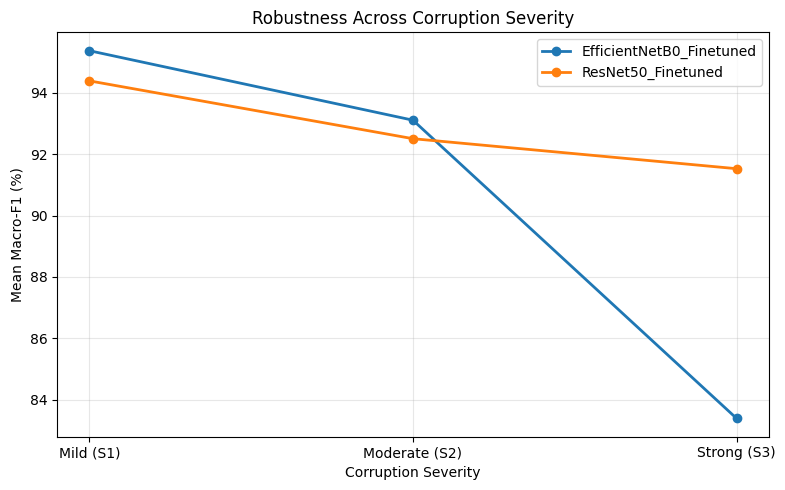

✅ Saved: /kaggle/working/phaseE_severity_macro_f1.png


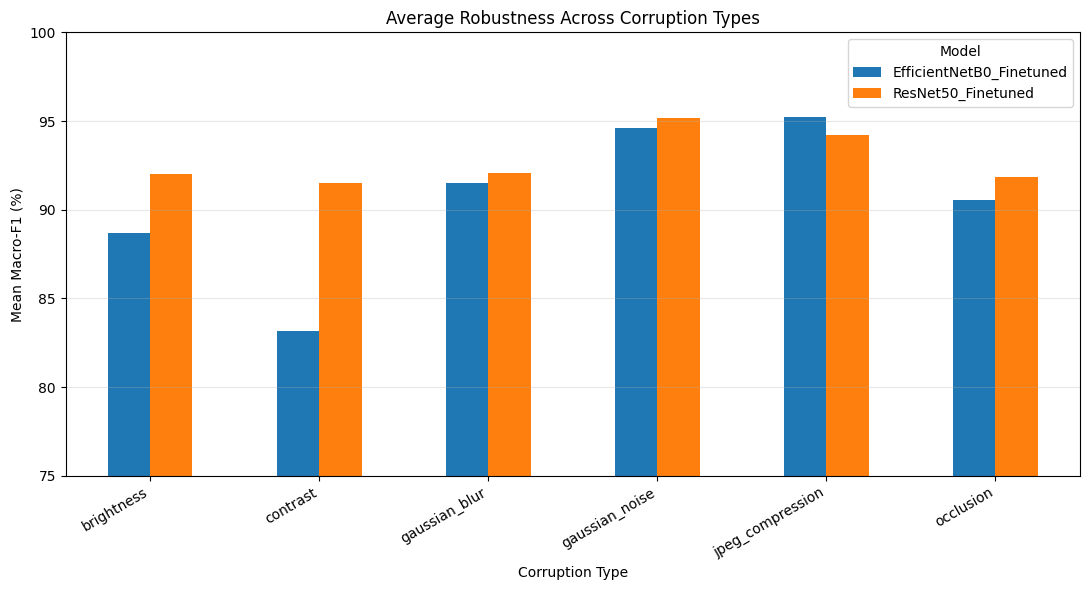

✅ Saved: /kaggle/working/phaseE_corruption_macro_f1.png


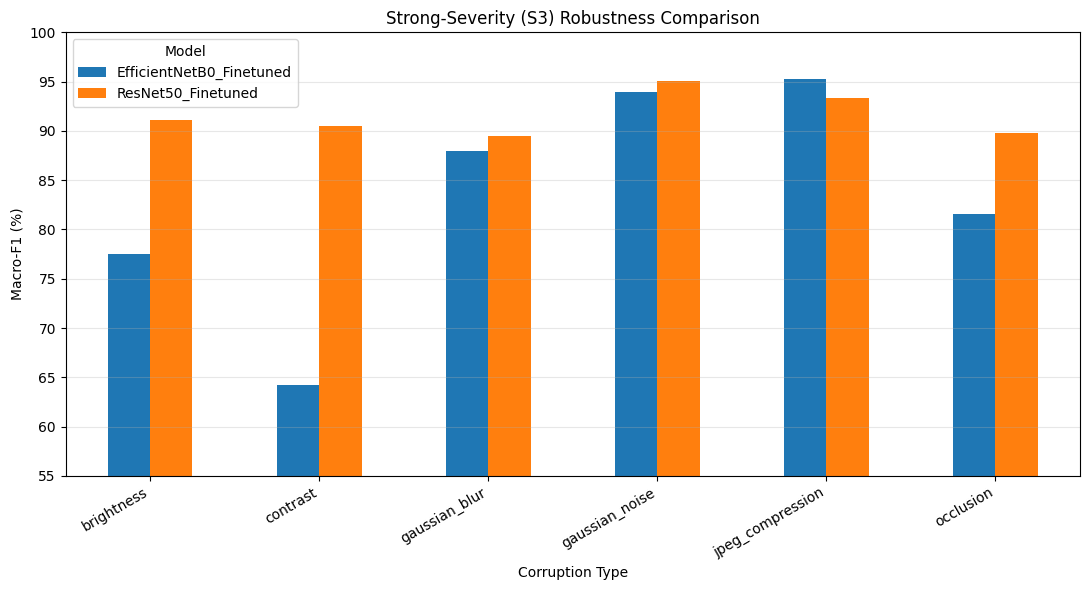

✅ Saved: /kaggle/working/phaseE_strong_severity_macro_f1.png


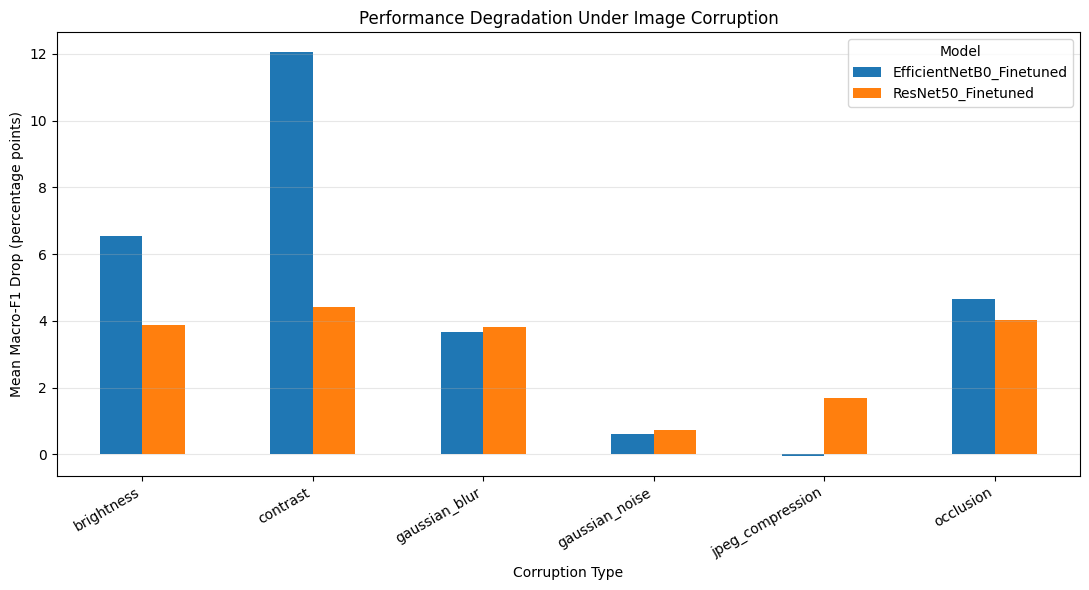

✅ Saved: /kaggle/working/phaseE_macro_f1_drop_by_corruption.png

✅ ALL PHASE E ROBUSTNESS FIGURES CREATED


In [10]:
# ============================================================
# PHASE E — CELL 9
# PUBLICATION-READY ROBUSTNESS FIGURES
# ============================================================


# ============================================================
# FIGURE 1
# SEVERITY-WISE MACRO-F1
# ============================================================

plt.figure(
    figsize=(8, 5)
)


for model_name in severity_summary_df["Model"].unique():

    temp = severity_summary_df[
        severity_summary_df["Model"] == model_name
    ].sort_values(
        "Severity"
    )


    plt.plot(

        temp["Severity"],

        temp["Macro-F1 (%)"],

        marker="o",

        linewidth=2,

        label=model_name
    )


plt.xticks(
    [1, 2, 3],
    [
        "Mild (S1)",
        "Moderate (S2)",
        "Strong (S3)"
    ]
)


plt.xlabel(
    "Corruption Severity"
)

plt.ylabel(
    "Mean Macro-F1 (%)"
)

plt.title(
    "Robustness Across Corruption Severity"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()


SEVERITY_PLOT = (

    "/kaggle/working/"
    "phaseE_severity_macro_f1.png"
)


plt.savefig(

    SEVERITY_PLOT,

    dpi=300,

    bbox_inches="tight"
)

plt.show()


print(
    "✅ Saved:",
    SEVERITY_PLOT
)


# ============================================================
# FIGURE 2
# CORRUPTION-WISE AVERAGE MACRO-F1
# ============================================================

corruption_pivot = (

    corruption_summary_df

    .pivot(

        index="Corruption",

        columns="Model",

        values="Macro-F1 (%)"
    )

)


corruption_pivot.plot(

    kind="bar",

    figsize=(11, 6)
)


plt.ylabel(
    "Mean Macro-F1 (%)"
)

plt.xlabel(
    "Corruption Type"
)

plt.title(
    "Average Robustness Across Corruption Types"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.ylim(
    75,
    100
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.legend(
    title="Model"
)

plt.tight_layout()


CORRUPTION_PLOT = (

    "/kaggle/working/"
    "phaseE_corruption_macro_f1.png"
)


plt.savefig(

    CORRUPTION_PLOT,

    dpi=300,

    bbox_inches="tight"
)

plt.show()


print(
    "✅ Saved:",
    CORRUPTION_PLOT
)


# ============================================================
# FIGURE 3
# STRONG-SEVERITY S3 PERFORMANCE
# ============================================================

strong_plot_df = (

    robustness_df[
        robustness_df["Severity"] == 3
    ]

    .pivot(

        index="Corruption",

        columns="Model",

        values="Macro-F1 (%)"
    )

)


strong_plot_df.plot(

    kind="bar",

    figsize=(11, 6)
)


plt.ylabel(
    "Macro-F1 (%)"
)

plt.xlabel(
    "Corruption Type"
)

plt.title(
    "Strong-Severity (S3) Robustness Comparison"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.ylim(
    55,
    100
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.legend(
    title="Model"
)

plt.tight_layout()


STRONG_PLOT = (

    "/kaggle/working/"
    "phaseE_strong_severity_macro_f1.png"
)


plt.savefig(

    STRONG_PLOT,

    dpi=300,

    bbox_inches="tight"
)

plt.show()


print(
    "✅ Saved:",
    STRONG_PLOT
)


# ============================================================
# FIGURE 4
# MACRO-F1 DROP BY CORRUPTION
# ============================================================

drop_pivot = (

    corruption_summary_df

    .pivot(

        index="Corruption",

        columns="Model",

        values="Macro-F1 Drop (pp)"
    )

)


drop_pivot.plot(

    kind="bar",

    figsize=(11, 6)
)


plt.ylabel(
    "Mean Macro-F1 Drop (percentage points)"
)

plt.xlabel(
    "Corruption Type"
)

plt.title(
    "Performance Degradation Under Image Corruption"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.legend(
    title="Model"
)

plt.tight_layout()


DROP_PLOT = (

    "/kaggle/working/"
    "phaseE_macro_f1_drop_by_corruption.png"
)


plt.savefig(

    DROP_PLOT,

    dpi=300,

    bbox_inches="tight"
)

plt.show()


print(
    "✅ Saved:",
    DROP_PLOT
)


print(
    "\n" + "=" * 72
)

print(
    "✅ ALL PHASE E ROBUSTNESS FIGURES CREATED"
)

print("=" * 72)

In [11]:
# ============================================================
# PHASE E — CELL 10
# FINAL METADATA + COMPLETE BACKUP ZIP
# ============================================================

import os
import json
import zipfile


# ============================================================
# PHASE E METADATA
# ============================================================

phaseE_metadata = {

    "phase":
        "Phase E — Corruption Robustness Evaluation",

    "seed":
        SEED,

    "test_images":
        len(clean_test_dataset),

    "num_classes":
        NUM_CLASSES,

    "image_size":
        IMG_SIZE,

    "models": [
        "ResNet50_Finetuned",
        "EfficientNetB0_Finetuned"
    ],

    "clean_baselines": {

        "ResNet50_Finetuned": {
            "accuracy_percent":
                resnet_clean["accuracy"] * 100,

            "macro_f1_percent":
                resnet_clean["macro_f1"] * 100
        },

        "EfficientNetB0_Finetuned": {
            "accuracy_percent":
                effnet_clean["accuracy"] * 100,

            "macro_f1_percent":
                effnet_clean["macro_f1"] * 100
        }
    },

    "corruptions":
        CORRUPTIONS,

    "severity_levels": {
        "1": "Mild",
        "2": "Moderate",
        "3": "Strong"
    },

    "corruption_parameters":
        CORRUPTION_PARAMS,

    "total_corrupted_conditions":
        18,

    "total_model_evaluations":
        36,

    "severity_consistent_randomization":
        True,

    "gaussian_noise_note":
        "Same random noise pattern across S1-S3; only magnitude changes.",

    "occlusion_note":
        "Same spatial center across S1-S3; only occluded area changes.",

    "training_performed":
        False,

    "tuning_performed":
        False,

    "device":
        str(DEVICE)
}


METADATA_PATH = (
    "/kaggle/working/"
    "phaseE_metadata.json"
)


with open(
    METADATA_PATH,
    "w"
) as f:

    json.dump(
        phaseE_metadata,
        f,
        indent=2
    )


print(
    "✅ Metadata saved:"
)

print(
    METADATA_PATH
)


# ============================================================
# COLLECT PHASE E OUTPUT FILES
# ============================================================

files_to_backup = []


for filename in os.listdir(
    "/kaggle/working"
):

    full_path = os.path.join(
        "/kaggle/working",
        filename
    )


    if not os.path.isfile(
        full_path
    ):
        continue


    if filename.startswith(
        "phaseE_"
    ):

        if filename.endswith(
            (
                ".csv",
                ".png",
                ".json",
                ".npz"
            )
        ):

            files_to_backup.append(
                full_path
            )


# ============================================================
# CREATE FINAL ZIP
# ============================================================

PHASE_E_ZIP = (

    "/kaggle/working/"
    "AquaPlant_PhaseE_Robustness_Artifacts.zip"
)


with zipfile.ZipFile(

    PHASE_E_ZIP,

    "w",

    zipfile.ZIP_DEFLATED

) as zipf:


    for file_path in files_to_backup:

        zipf.write(

            file_path,

            arcname=os.path.basename(
                file_path
            )
        )


# ============================================================
# VERIFY ZIP
# ============================================================

with zipfile.ZipFile(
    PHASE_E_ZIP,
    "r"
) as zipf:

    bad_file = zipf.testzip()

    zip_contents = zipf.namelist()


assert bad_file is None


print(
    "\n" + "=" * 75
)

print(
    "PHASE E FINAL BACKUP"
)

print("=" * 75)


print(
    "ZIP:"
)

print(
    PHASE_E_ZIP
)


print(
    "\nFiles included:",
    len(zip_contents)
)


for file in sorted(
    zip_contents
):

    print(
        " -",
        file
    )


print(
    "\nZIP size:",
    f"{os.path.getsize(PHASE_E_ZIP) / (1024 ** 2):.2f} MB"
)


print(
    "\n✅ ZIP integrity check PASSED"
)

print(
    "✅ PHASE E ROBUSTNESS EVALUATION COMPLETE"
)

print(
    "✅ Download AquaPlant_PhaseE_Robustness_Artifacts.zip"
)

✅ Metadata saved:
/kaggle/working/phaseE_metadata.json

PHASE E FINAL BACKUP
ZIP:
/kaggle/working/AquaPlant_PhaseE_Robustness_Artifacts.zip

Files included: 11
 - phaseE_all_corruption_results.csv
 - phaseE_corruption_macro_f1.png
 - phaseE_corruption_preview.png
 - phaseE_corruption_summary.csv
 - phaseE_macro_f1_drop_by_corruption.png
 - phaseE_metadata.json
 - phaseE_overall_robustness_summary.csv
 - phaseE_severity_macro_f1.png
 - phaseE_severity_summary.csv
 - phaseE_strong_severity_macro_f1.png
 - phaseE_strong_severity_summary.csv

ZIP size: 28.24 MB

✅ ZIP integrity check PASSED
✅ PHASE E ROBUSTNESS EVALUATION COMPLETE
✅ Download AquaPlant_PhaseE_Robustness_Artifacts.zip
